# 模型配置

> 前面几节，我们一直在从零实现：写 Tokenizer、搭 Embedding、堆 Transformer Block——所有结构参数都硬编码在 Python 代码里，改一个隐藏维度要重新改代码。但真实世界的大模型不是这样组织和分发的。
>
> 这一节打开 SmolLM2-135M 的仓库，看一个现代 LLM 到底由哪些文件构成，每个文件管什么，以及怎么用这些文件把模型加载起来、跑起来。从「写代码定义模型」切换到「读配置描述模型」。

一个典型的 HuggingFace 模型仓库（如 [SmolLM2-135M](https://huggingface.co/HuggingFaceTB/SmolLM2-135M/tree/main)）里，权重文件（.safetensors）只占了一半。另一半是几张 JSON 配置表，各自管一摊：

- config.json 管模型长什么样——多少层、多宽、几个头
- tokenizer_config.json 管文本怎么变成数字——加不加 BOS/EOS、最多切多长
- tokenizer.json 存 BPE 词表和合并规则，是 tokenizer_config.json 的「数据文件」
- generation_config.json 管模型怎么输出——temperature、top_p、top_k

这些文件合在一起，就是一份完整的模型说明书。

config.json 里写的每一个参数，都会对应到一个具体的 PyTorch 模块。

## 仓库文件地图：一张表看懂 HuggingFace 仓库

一个 HuggingFace 模型仓库通常包含这些文件。config.json 是必选项，其余取决于模型类型和配置方式。

In [1]:
files = [
    ("config.json",          "必选", "模型结构参数：层数、维度、头数、激活函数等"),
    ("tokenizer_config.json", "标配", "分词器行为：特殊 token、最大长度、截断/填充策略"),
    ("generation_config.json","标配", "生成策略：temperature、top_p、top_k、repetition_penalty"),
    ("tokenizer.json",        "标配", "分词器模型文件（BPE 词表 + 合并规则），通常几 MB"),
    ("special_tokens_map.json","可选", "特殊 token 的名称到 ID 映射"),
    ("vocab.json",            "部分", "BPE 词表（如 GPT-2），从 token 字符串到 ID"),
    ("merges.txt",            "部分", "BPE 合并规则（如 GPT-2），按优先级排列"),
]

print(f"{'文件名':<28} {'必要性':<8} {'用途'}")
print("-" * 80)
for name, required, purpose in files:
    print(f"{name:<28} {required:<8} {purpose}")


文件名                          必要性      用途
--------------------------------------------------------------------------------
config.json                  必选       模型结构参数：层数、维度、头数、激活函数等
tokenizer_config.json        标配       分词器行为：特殊 token、最大长度、截断/填充策略
generation_config.json       标配       生成策略：temperature、top_p、top_k、repetition_penalty
tokenizer.json               标配       分词器模型文件（BPE 词表 + 合并规则），通常几 MB
special_tokens_map.json      可选       特殊 token 的名称到 ID 映射
vocab.json                   部分       BPE 词表（如 GPT-2），从 token 字符串到 ID
merges.txt                   部分       BPE 合并规则（如 GPT-2），按优先级排列


## config.json：把结构参数变成 PyTorch 模块

下面是 SmolLM2-135M 的真实 config.json。接下来的每个小节，不是打印这些值的含义，而是**用它们建出对应的 PyTorch 模块**，验证形状、核算参数量。

In [2]:
config = {
    "architectures": ["LlamaForCausalLM"],
    "hidden_size": 576,
    "intermediate_size": 1536,
    "num_attention_heads": 9,
    "num_key_value_heads": 3,
    "num_hidden_layers": 30,
    "vocab_size": 49152,
    "max_position_embeddings": 8192,
    "hidden_act": "silu",
    "rms_norm_eps": 1e-05,
    "rope_theta": 100000,
    "tie_word_embeddings": True,
    "attention_bias": False,
}

V, D, L, H, KV, FF = (config[k] for k in (
    "vocab_size", "hidden_size", "num_hidden_layers",
    "num_attention_heads", "num_key_value_heads", "intermediate_size"))
head_dim = D // H

**TransformerBlock —— 用 config 组装一个完整的 Block**

config.json 里的参数最终要装进一个 TransformerBlock：Attention（GQA）+ FFN（SwiGLU）+ RMSNorm。
下面直接用 PyTorch 自带的模块（`nn.Linear`、`nn.RMSNorm`），用 config 数字把它们拼起来，然后打印它的结构。

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class TransformerBlock(nn.Module):
    """TransformerBlock：RMSNorm → GQA Attention → RMSNorm → SwiGLU FFN"""
    def __init__(self, config):
        super().__init__()
        d = config['hidden_size']
        ff = config['intermediate_size']
        h = config['num_attention_heads']
        kv = config['num_key_value_heads']
        hd = d // h
        bias = config['attention_bias']

        self.attn_norm = nn.RMSNorm(d, eps=config['rms_norm_eps'])
        self.ffn_norm  = nn.RMSNorm(d, eps=config['rms_norm_eps'])
        # Attention 四个投影
        self.q_proj = nn.Linear(d, h * hd, bias=bias)
        self.k_proj = nn.Linear(d, kv * hd, bias=bias)
        self.v_proj = nn.Linear(d, kv * hd, bias=bias)
        self.o_proj = nn.Linear(h * hd, d, bias=bias)
        # FFN 三个投影
        self.gate = nn.Linear(d, ff, bias=False)
        self.up   = nn.Linear(d, ff, bias=False)
        self.down = nn.Linear(ff, d, bias=False)

        self.n_heads = h
        self.n_kv_heads = kv
        self.head_dim = hd

    def forward(self, x):
        # Attention (简化版，不包含 causal mask 和 RoPE)
        residual = x
        x = self.attn_norm(x)
        B, T, D = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        # GQA 广播
        k = k.repeat_interleave(self.n_heads // self.n_kv_heads, dim=1)
        v = v.repeat_interleave(self.n_heads // self.n_kv_heads, dim=1)
        scale = self.head_dim ** -0.5
        attn = (q @ k.transpose(-2, -1)) * scale
        attn = F.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, D)
        x = residual + self.o_proj(out)
        # FFN
        residual = x
        x = self.ffn_norm(x)
        x = residual + self.down(F.silu(self.gate(x)) * self.up(x))
        return x

# 用 SmolLM2 的 config 建一个 Block
block = TransformerBlock(config)
print("=== 单个 TransformerBlock 的完整结构 ===")
print(block)
block_params = sum(p.numel() for p in block.parameters())
print(f"\n这个 Block 的参数量: {block_params:,}  ({block_params/1e6:.2f}M)")


=== 单个 TransformerBlock 的完整结构 ===
TransformerBlock(
  (attn_norm): RMSNorm((576,), eps=1e-05, elementwise_affine=True)
  (ffn_norm): RMSNorm((576,), eps=1e-05, elementwise_affine=True)
  (q_proj): Linear(in_features=576, out_features=576, bias=False)
  (k_proj): Linear(in_features=576, out_features=192, bias=False)
  (v_proj): Linear(in_features=576, out_features=192, bias=False)
  (o_proj): Linear(in_features=576, out_features=576, bias=False)
  (gate): Linear(in_features=576, out_features=1536, bias=False)
  (up): Linear(in_features=576, out_features=1536, bias=False)
  (down): Linear(in_features=1536, out_features=576, bias=False)
)

这个 Block 的参数量: 3,540,096  (3.54M)


**Attention —— GQA 让 K/V 投影比 Q 小**

num_attention_heads=9、num_key_value_heads=3、attention_bias=false。
Q 投影是 [576, 9×64]，K/V 投影是 [576, 3×64]——K 和 V 的参数只有 Q 的 1/3。
建出四个投影矩阵，看形状直接验证。

In [4]:
import torch
import torch.nn as nn

torch.manual_seed(42)

W_q = nn.Linear(D, H * head_dim, bias=False)
W_k = nn.Linear(D, KV * head_dim, bias=False)
W_v = nn.Linear(D, KV * head_dim, bias=False)
W_o = nn.Linear(H * head_dim, D, bias=False)

x = torch.randn(2, 16, D)  # 模拟 hidden states
q = W_q(x).view(2, 16, H, head_dim).transpose(1, 2)   # [2, 9, 16, 64]
k = W_k(x).view(2, 16, KV, head_dim).transpose(1, 2)  # [2, 3, 16, 64]
v = W_v(x).view(2, 16, KV, head_dim).transpose(1, 2)  # [2, 3, 16, 64]

print(f"输入: [2, 16, {D}]")
print(f"Q 投影: {list(W_q.weight.shape)} → Q shape: {list(q.shape)}")
print(f"K 投影: {list(W_k.weight.shape)} → K shape: {list(k.shape)}")
print(f"V 投影: {list(W_v.weight.shape)} → V shape: {list(v.shape)}")
print(f"O 投影: {list(W_o.weight.shape)}")
print()
q_p = sum(p.numel() for p in W_q.parameters())
k_p = sum(p.numel() for p in W_k.parameters())
print(f"Q 参数: {q_p:,}   K 参数: {k_p:,}   K/Q = {k_p/q_p:.2f}")
print(f"如果是 MHA (Q=K=V=9): K 参数也会是 {q_p:,}")
print(f"GQA 节省了 {(q_p - k_p) * 30:,.0f} 个 K+V 参数 (30 层合计)")


输入: [2, 16, 576]
Q 投影: [576, 576] → Q shape: [2, 9, 16, 64]
K 投影: [192, 576] → K shape: [2, 3, 16, 64]
V 投影: [192, 576] → V shape: [2, 3, 16, 64]
O 投影: [576, 576]

Q 参数: 331,776   K 参数: 110,592   K/Q = 0.33
如果是 MHA (Q=K=V=9): K 参数也会是 331,776
GQA 节省了 6,635,520 个 K+V 参数 (30 层合计)


GQA 的核心是在 Attention 计算时把 KV 头「广播」给 Q 头。下面用一个小例子模拟这个过程：

In [5]:
groups = H // KV  # 每组 3 个 Q 头
k_repeated = k.repeat_interleave(groups, dim=1)  # [2, 3, 16, 64] → [2, 9, 16, 64]
v_repeated = v.repeat_interleave(groups, dim=1)

# 现在 Q 和 K 头数一致了，可以正常做 Attention
scale = head_dim ** -0.5
attn_weights = (q @ k_repeated.transpose(-2, -1)) * scale  # [2, 9, 16, 16]

print(f"K 原始形状: {list(k.shape)}  → repeat_interleave({groups}) → {list(k_repeated.shape)}")
print(f"V 原始形状: {list(v.shape)}  → repeat_interleave({groups}) → {list(v_repeated.shape)}")
print(f"QK^T 结果:   {list(attn_weights.shape)}")
print(f"\n分组关系:")
for kv_idx in range(KV):
    q_idx = list(range(kv_idx * groups, (kv_idx + 1) * groups))
    print(f"  KV[{kv_idx}] → Q{q_idx}")

K 原始形状: [2, 3, 16, 64]  → repeat_interleave(3) → [2, 9, 16, 64]
V 原始形状: [2, 3, 16, 64]  → repeat_interleave(3) → [2, 9, 16, 64]
QK^T 结果:   [2, 9, 16, 16]

分组关系:
  KV[0] → Q[0, 1, 2]
  KV[1] → Q[3, 4, 5]
  KV[2] → Q[6, 7, 8]


**FFN —— SwiGLU 的三权重结构**

读 config 时，FFN 重点看两个数字：

- `hidden_size`：Block 内部统一宽度，也就是 05 节里的 `d_model`
- `intermediate_size`：FFN 中间层宽度，也就是 05 节里的 `d_ff`

SmolLM2-135M 里 `hidden_size=576`，`intermediate_size=1536`。这表示每个 token 先从 576 维升到 1536 维，在更宽的空间里加工，再降回 576 维。

Llama-style 的 FFN 和 05 节最简单的两层 FFN 不同：它有三个权重矩阵（gate、up、down），activation 用 SiLU。

```text
教学版 FFN:
  x → up_proj → ReLU/GELU → down_proj → out

SwiGLU FFN:
  x → up_proj   ┐
  x → gate_proj ├→ SiLU(gate) * up → down_proj → out
```

所以参数量也不同：教学版主要是 2 个矩阵，SwiGLU 是 3 个矩阵。下面建出来，做一次前向，验证形状变化。

In [6]:
import torch.nn as nn
import torch.nn.functional as F

import torch

class LlamaFFN(nn.Module):
    """Llama 风格的 SwiGLU FFN：gate 做门控，up 做投影，down 收回来"""
    def __init__(self, dim, intermediate_dim):
        super().__init__()
        self.gate = nn.Linear(dim, intermediate_dim, bias=False)
        self.up   = nn.Linear(dim, intermediate_dim, bias=False)
        self.down = nn.Linear(intermediate_dim, dim, bias=False)

    def forward(self, x):
        return self.down(F.silu(self.gate(x)) * self.up(x))

ffn = LlamaFFN(D, FF)
x = torch.randn(2, 16, D)
out = ffn(x)

gate_p = sum(p.numel() for p in ffn.gate.parameters())
up_p   = sum(p.numel() for p in ffn.up.parameters())
down_p = sum(p.numel() for p in ffn.down.parameters())

print(f"LlamaFFN 结构:")
print(f"  gate: {list(ffn.gate.weight.shape)}  ({gate_p:,} params)")
print(f"  up:   {list(ffn.up.weight.shape)}  ({up_p:,} params)")
print(f"  down: {list(ffn.down.weight.shape)}  ({down_p:,} params)")
print(f"  合计: {gate_p + up_p + down_p:,} params")
print(f"\n前向: [2, 16, {D}] → gate/up → [2, 16, {FF}] → SiLU · up → down → [2, 16, {D}]")
print(f"输入 shape: {list(x.shape)}  输出 shape: {list(out.shape)}")
print(f"05 节对比: 两权重 FFN ({D}→{D*4}→{D}), 这里三权重 ({D}→{FF}→{D}), 多了一个 gate")


LlamaFFN 结构:
  gate: [1536, 576]  (884,736 params)
  up:   [1536, 576]  (884,736 params)
  down: [576, 1536]  (884,736 params)
  合计: 2,654,208 params

前向: [2, 16, 576] → gate/up → [2, 16, 1536] → SiLU · up → down → [2, 16, 576]
输入 shape: [2, 16, 576]  输出 shape: [2, 16, 576]
05 节对比: 两权重 FFN (576→2304→576), 这里三权重 (576→1536→576), 多了一个 gate


**RMSNorm —— 只缩放不平移**

05 节用的是 LayerNorm（平移 + 缩放）。现代 LLM 几乎全用 RMSNorm——只做缩放，
省掉平移这一步。config 里 rms_norm_eps=1e-05。PyTorch 1.13 起内置了 nn.RMSNorm，
直接打印它的结构，和 nn.LayerNorm 对比。

In [7]:
# 直接用 PyTorch 内置的 RMSNorm 和 LayerNorm
import torch
import torch.nn as nn

rn = nn.RMSNorm(D, eps=config['rms_norm_eps'])
ln = nn.LayerNorm(D, eps=config['rms_norm_eps'])

print("=== nn.RMSNorm 结构 ===")
print(rn)
print("\n=== nn.LayerNorm 结构 ===")
print(ln)

# 同一份随机输入
x = torch.randn(4, 8, D)
with torch.no_grad():
    ln_out = ln(x)
    rn_out = rn(x)

print(f"\nLayerNorm:  weight + bias = {sum(p.numel() for p in ln.parameters())} 个参数")
print(f"RMSNorm:   只有 weight    = {sum(p.numel() for p in rn.parameters())} 个参数")
print(f"\n归一化前:  mean={x.mean():.3f}, std={x.std():.3f}")
print(f"LayerNorm: mean={ln_out.mean():.6f}, std={ln_out.std():.3f}  ← 均值为 0")
print(f"RMSNorm:   mean={rn_out.mean():.4f}, std={rn_out.std():.3f}  ← 均值不为 0")
print(f"\n每层省 {D} 个 bias 参数，30 层合计省 {D * 30:,} 个")


=== nn.RMSNorm 结构 ===
RMSNorm((576,), eps=1e-05, elementwise_affine=True)

=== nn.LayerNorm 结构 ===
LayerNorm((576,), eps=1e-05, elementwise_affine=True)

LayerNorm:  weight + bias = 1152 个参数
RMSNorm:   只有 weight    = 576 个参数

归一化前:  mean=0.012, std=1.001
LayerNorm: mean=0.000000, std=1.000  ← 均值为 0
RMSNorm:   mean=0.0115, std=1.000  ← 均值不为 0

每层省 576 个 bias 参数，30 层合计省 17,280 个


**核算总参数量**

现在已经有了所有组件的尺寸。下面分两步验证 135M 这个数字：
第一步用公式逐项算（理论），第二步把完整模型建出来、用 `sum(p.numel())` 算（真实），看两者是否对得上。

In [8]:
# ========== 理论计算：逐项按公式算 ==========
# 每层 Attention: Q, K, V, O 四个投影
import torch.nn as nn
import torch.nn.functional as F

q_p  = D * H * head_dim       # Q: [D, H*head_dim]
k_p  = D * KV * head_dim      # K: [D, KV*head_dim]
v_p  = D * KV * head_dim      # V: [D, KV*head_dim]
o_p  = H * head_dim * D       # O: [H*head_dim, D]
attn_p = q_p + k_p + v_p + o_p

# 每层 FFN: gate, up, down 三个投影
ffn_p = 3 * D * FF

# 每层 Norm: 2 个 RMSNorm，每个只有 D 个 weight
norm_p = 2 * D

per_layer = attn_p + ffn_p + norm_p
total_theory = V * D + L * per_layer + D  # Embedding + 30层 + 最终Norm

print("========== 理论计算（公式） ==========")
print(f"每层 Attention (Q+K+V+O): {attn_p:>10,}")
print(f"每层 FFN (gate+up+down):   {ffn_p:>10,}")
print(f"每层 RMSNorm × 2:          {norm_p:>10,}")
print(f"每层小计:                  {per_layer:>10,} ≈ {per_layer/1e6:.2f}M")
print(f"\nEmbedding ({V}×{D}):       {V*D:>10,} ≈ {V*D/1e6:.1f}M")
print(f"{L} 层 Block:              {L*per_layer:>10,} ≈ {L*per_layer/1e6:.1f}M")
print(f"最终 RMSNorm:              {D:>10,}")
print(f"理论总计:                  {total_theory:>10,} ≈ {total_theory/1e6:.1f}M")

# ========== 真实计算：建出完整模型，用 sum(p.numel()) 算 ==========
class SmolLM2ConfigModel(nn.Module):
    """用 config 组装 SmolLM2：Embedding → 30×Block → RMSNorm → 输出投影"""
    def __init__(self, config):
        super().__init__()
        d, V = config['hidden_size'], config['vocab_size']
        self.embed = nn.Embedding(V, d)
        self.blocks = nn.ModuleList(
            [TransformerBlock(config) for _ in range(config['num_hidden_layers'])])
        self.final_norm = nn.RMSNorm(d, eps=config['rms_norm_eps'])

    def forward(self, x):
        x = self.embed(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.final_norm(x)
        # tie_word_embeddings=True：输出投影复用 embed.weight，不另建 lm_head
        return F.linear(x, self.embed.weight)

model = SmolLM2ConfigModel(config)
total_real = sum(p.numel() for p in model.parameters())

print("\n========== 真实计算 (sum(p.numel())) ==========")
emb_real = sum(p.numel() for p in model.embed.parameters())
blocks_real = sum(p.numel() for p in model.blocks.parameters())
norm_real = sum(p.numel() for p in model.final_norm.parameters())
print(f"Embedding:     {emb_real:>10,}  ({V}×{D})")
print(f"30×Block:      {blocks_real:>10,}  ({L}×{per_layer:,})")
print(f"final_norm:    {norm_real:>10,}  ({D})")
print(f"{'─'*45}")
print(f"真实总计:      {total_real:>10,} ≈ {total_real/1e6:.1f}M")

print(f"\n========== 对照 ==========")
print(f"理论计算: {total_theory:,}")
print(f"真实计算: {total_real:,}")
print(f"两者一致: {total_theory == total_real}")
if total_theory == total_real:
    print("✓ 理论公式和 PyTorch 实际参数完全对上了")
else:
    print(f"✗ 差 {abs(total_theory - total_real):,}，请检查")


========== 理论计算（公式） ==========
每层 Attention (Q+K+V+O):    884,736
每层 FFN (gate+up+down):    2,654,208
每层 RMSNorm × 2:               1,152
每层小计:                   3,540,096 ≈ 3.54M

Embedding (49152×576):       28,311,552 ≈ 28.3M
30 层 Block:              106,202,880 ≈ 106.2M
最终 RMSNorm:                     576
理论总计:                  134,515,008 ≈ 134.5M



========== 真实计算 (sum(p.numel())) ==========
Embedding:     28,311,552  (49152×576)
30×Block:      106,202,880  (30×3,540,096)
final_norm:           576  (576)
─────────────────────────────────────────────
真实总计:      134,515,008 ≈ 134.5M

========== 对照 ==========
理论计算: 134,515,008
真实计算: 134,515,008
两者一致: True
✓ 理论公式和 PyTorch 实际参数完全对上了


参数都花在哪了：

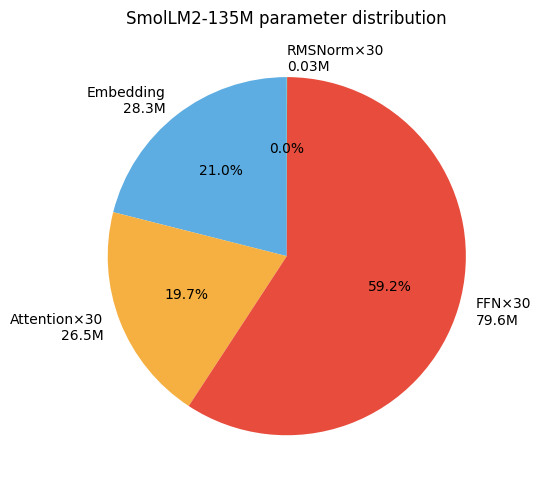

In [9]:
import matplotlib.pyplot as plt

emb_s = V * D
attn_s = attn_p * L
ffn_s = ffn_p * L
norm_s = norm_p * L

labels = [f'Embedding\n{emb_s/1e6:.1f}M', f'Attention×{L}\n{attn_s/1e6:.1f}M',
          f'FFN×{L}\n{ffn_s/1e6:.1f}M', f'RMSNorm×{L}\n{norm_s/1e6:.2f}M']
sizes = [emb_s, attn_s, ffn_s, norm_s]

plt.figure(figsize=(6, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['#5DADE2','#F5B041','#E74C3C','#58D68D'])
plt.title(f'SmolLM2-135M parameter distribution')
plt.tight_layout()
plt.show()

## tokenizer_config.json：控制文本怎么被翻译成数字

config.json 只管模型内部。文本进入模型之前和之后，都由 tokenizer_config.json 和 tokenizer.json 接管。
tokenizer_config.json 定义「特殊 token 是什么」「最多切多长」「要不要加 BOS/EOS」这些行为参数。

下面用 SmolLM2 的 tokenizer 配置（精简版），演示这些参数实际影响什么。

In [10]:
import json

tokenizer_config = {
    "add_bos_token": True,
    "add_eos_token": True,
    "bos_token": "<|im_start|>",
    "eos_token": "<|im_end|>",
    "pad_token": "<|im_end|>",
    "model_max_length": 8192,
    "truncation_side": "right",
    "padding_side": "right",
}

print("tokenizer_config.json (精简):")
print(json.dumps(tokenizer_config, indent=2, ensure_ascii=False))


tokenizer_config.json (精简):
{
  "add_bos_token": true,
  "add_eos_token": true,
  "bos_token": "<|im_start|>",
  "eos_token": "<|im_end|>",
  "pad_token": "<|im_end|>",
  "model_max_length": 8192,
  "truncation_side": "right",
  "padding_side": "right"
}


tokenizer_config 里的参数直接影响 encode 的结果。
我们用一个小词表模拟 encode 过程，展示 BOS/EOS 的插入、padding、截断是怎么运作的：

In [11]:
# 模拟一个小词表（SmolLM2 实际词表有 49152 个 token，这里用 10 个示意）
mini_vocab = {"<|im_start|>": 0, "<|im_end|>": 1, "我": 2, "爱": 3, "机器": 4, "学习": 5, "。": 6}

def simulate_encode(text, cfg):
    """模拟 tokenizer 的 encode 行为：切词 + 加特殊 token"""
    # 极简切词：每字一个 token（真 tokenizer 会用 BPE，但行为模式相同）
    tokens = [c for c in text]
    ids = [mini_vocab.get(t, -1) for t in tokens]
    if cfg.get("add_bos_token"):
        ids = [mini_vocab[cfg["bos_token"]]] + ids
    if cfg.get("add_eos_token"):
        ids = ids + [mini_vocab[cfg["eos_token"]]]
    return ids

# 不同设置下的 encode 结果
text = "我爱机器学习"

cfg_with_both = {"add_bos_token": True, "add_eos_token": True, "bos_token": "<|im_start|>", "eos_token": "<|im_end|>"}
cfg_without   = {"add_bos_token": False, "add_eos_token": False}
cfg_bos_only  = {"add_bos_token": True, "add_eos_token": False, "bos_token": "<|im_start|>", "eos_token": "<|im_end|>"}

print(f"原文: '{text}'\n")
print(f"add_bos=True, add_eos=True:  {simulate_encode(text, cfg_with_both)}")
print(f"add_bos=False, add_eos=False: {simulate_encode(text, cfg_without)}")
print(f"add_bos=True, add_eos=False:  {simulate_encode(text, cfg_bos_only)}")
print(f"\n关键观察：BOS/EOS 的插入由 tokenizer_config 控制，不是模型自己决定的。")

原文: '我爱机器学习'

add_bos=True, add_eos=True:  [0, 2, 3, -1, -1, -1, -1, 1]
add_bos=False, add_eos=False: [2, 3, -1, -1, -1, -1]
add_bos=True, add_eos=False:  [0, 2, 3, -1, -1, -1, -1]

关键观察：BOS/EOS 的插入由 tokenizer_config 控制，不是模型自己决定的。


In [12]:
# Padding 演示：不同长度的句子怎么对齐
sentences = ["我爱机器学习", "猫", "深度学习很有意思"]
encoded = [simulate_encode(s, cfg_with_both) for s in sentences]
max_len = max(len(e) for e in encoded)

print("Padding 演示 (pad_token_id = 1 = <|im_end|>):\n")
for i, (s, ids) in enumerate(zip(sentences, encoded)):
    pad_len = max_len - len(ids)
    padded = ids + [1] * pad_len  # 用 pad_token_id 填充
    print(f"  '{s}':  {ids} → padded: {padded}")

print(f"\npadding_side = '{tokenizer_config['padding_side']}' → 在右边补 pad")
print(f"model_max_length = {tokenizer_config['model_max_length']} → 超过此长度会被截断")

Padding 演示 (pad_token_id = 1 = <|im_end|>):

  '我爱机器学习':  [0, 2, 3, -1, -1, -1, -1, 1] → padded: [0, 2, 3, -1, -1, -1, -1, 1, 1, 1]
  '猫':  [0, -1, 1] → padded: [0, -1, 1, 1, 1, 1, 1, 1, 1, 1]
  '深度学习很有意思':  [0, -1, -1, -1, -1, -1, -1, -1, -1, 1] → padded: [0, -1, -1, -1, -1, -1, -1, -1, -1, 1]

padding_side = 'right' → 在右边补 pad
model_max_length = 8192 → 超过此长度会被截断


## generation_config.json：控制模型怎么说话

模型算出每个位置对所有 token 的 logits 之后，下一个 token 怎么选？
这就是 generation_config.json 管的事。temperature、top_p、top_k 三个参数决定了采样策略，
它们各自的效果用一个具体例子就能看清楚。

In [13]:
import json

generation_config = {
    "temperature": 0.6,
    "top_p": 0.9,
    "top_k": 50,
    "max_new_tokens": 256,
    "do_sample": True,
    "repetition_penalty": 1.1,
    "eos_token_id": 0,
    "pad_token_id": 0,
}

print("generation_config.json:")
print(json.dumps(generation_config, indent=2, ensure_ascii=False))


generation_config.json:
{
  "temperature": 0.6,
  "top_p": 0.9,
  "top_k": 50,
  "max_new_tokens": 256,
  "do_sample": true,
  "repetition_penalty": 1.1,
  "eos_token_id": 0,
  "pad_token_id": 0
}


**temperature —— 调节确定性**

temperature 在 softmax 之前除以 logits。
T < 1 时概率分布变尖锐（高概率 token 更高，模型更确定），
T > 1 时概率分布变平缓（更多 token 有机会被选中，输出更随机）。

构造一个小词表 + 一组 logits，看 temperature 怎么改变实际的概率分布。

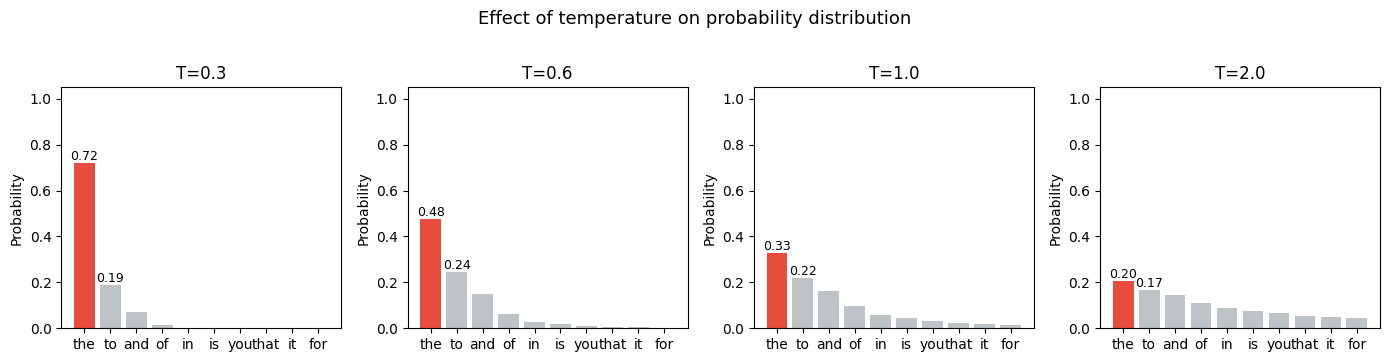

关键观察：T=0.3 时最高概率 token 几乎独占，T=2.0 时概率趋于均匀。
  SmolLM2 默认 T=0.6，偏保守，适合事实性任务。


In [14]:
import matplotlib.pyplot as plt
import numpy as np

import torch

tokens = ["the", "to", "and", "of", "in", "is", "you", "that", "it", "for"]
logits = torch.tensor([3.2, 2.8, 2.5, 2.0, 1.5, 1.2, 0.9, 0.6, 0.3, 0.1])

temperatures = [0.3, 0.6, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, T in zip(axes, temperatures):
    probs = torch.softmax(logits / T, dim=-1).numpy()
    ax.bar(range(len(tokens)), probs, color=['#E74C3C' if p == probs.max() else '#BDC3C7' for p in probs])
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"T={T}")
    ax.set_ylabel("Probability")
    # 标注最高概率
    top2 = np.argsort(probs)[-2:]
    ax.annotate(f"{probs[top2[0]]:.2f}", (top2[0], probs[top2[0]]), ha='center', va='bottom', fontsize=9)
    ax.annotate(f"{probs[top2[1]]:.2f}", (top2[1], probs[top2[1]]), ha='center', va='bottom', fontsize=9)

plt.suptitle("Effect of temperature on probability distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("关键观察：T=0.3 时最高概率 token 几乎独占，T=2.0 时概率趋于均匀。")
print(f"  SmolLM2 默认 T={generation_config['temperature']}，偏保守，适合事实性任务。")


**top_p (nucleus sampling) —— 只保留累积概率超过 p 的 token**

top_p 不是取概率最高的 k 个，而是从高到低累加，直到总概率达到 p 为止。
结果是被选中的 token 数量不固定——如果概率集中在头部就少，分布平坦就多。

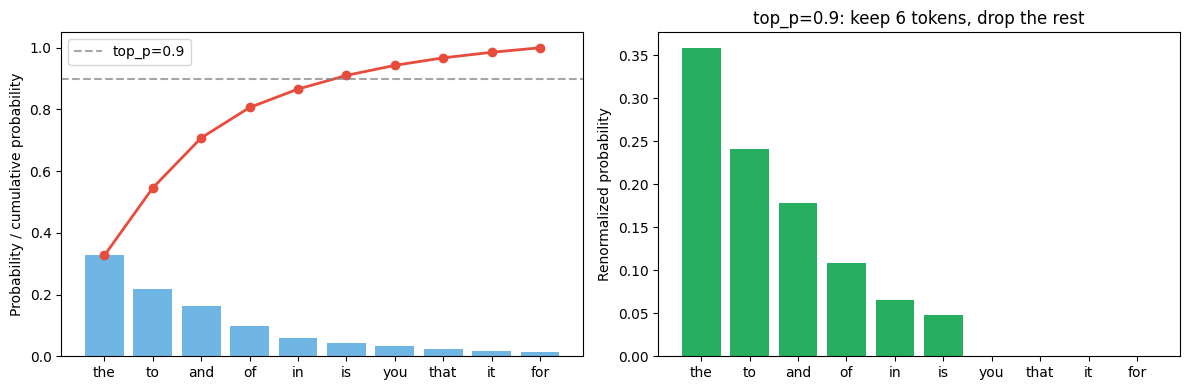

top_p=0.9: 保留了前 6 个 token (['the', 'to', 'and', 'of', 'in', 'is'])
被丢弃的 token: ['you', 'that', 'it', 'for']


In [15]:
import torch
import matplotlib.pyplot as plt

probs = torch.softmax(logits, dim=-1)
sorted_probs, sorted_indices = torch.sort(probs, descending=True)
cumsum = torch.cumsum(sorted_probs, dim=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 左图：累积概率
ax1.bar(range(len(tokens)), sorted_probs.numpy(), color='#3498DB', alpha=0.7)
ax1.plot(range(len(tokens)), cumsum.numpy(), 'o-', color='#E74C3C', linewidth=2, markersize=6)
ax1.axhline(y=0.9, color='gray', linestyle='--', alpha=0.7, label='top_p=0.9')
ax1.set_xticks(range(len(tokens)))
ax1.set_xticklabels([tokens[i] for i in sorted_indices])
ax1.set_ylabel("Probability / cumulative probability")
ax1.legend()

# 右图：top_p=0.9 后保留的 token
mask = cumsum <= 0.9
keep_n = mask.sum().item() + 1  # +1 是因为要包含第一个超过阈值的
keep_indices = sorted_indices[:keep_n]
keep_probs = probs[keep_indices]
filtered = torch.zeros_like(probs)
filtered[keep_indices] = keep_probs / keep_probs.sum()

ax2.bar(range(len(tokens)), filtered.numpy(),
        color=['#27AE60' if i in keep_indices else '#BDC3C7' for i in range(len(tokens))])
ax2.set_xticks(range(len(tokens)))
ax2.set_xticklabels(tokens)
ax2.set_ylabel("Renormalized probability")
ax2.set_title(f"top_p=0.9: keep {keep_n} tokens, drop the rest")

plt.tight_layout()
plt.show()

print(f"top_p=0.9: 保留了前 {keep_n} 个 token ({[tokens[i] for i in sorted_indices[:keep_n]]})")
print(f"被丢弃的 token: {[tokens[i] for i in sorted_indices[keep_n:]]}")


**top_k —— 最简单的截断**

只保留概率最高的 k 个 token。SmolLM2 的 top_k=50，
对于 49152 的词表来说只保留了 0.1% 的选项。
top_k 粗暴但有效：它只保留概率最高的 k 个候选，能降低采到长尾低概率 token 的机会，但不能保证输出一定合理。

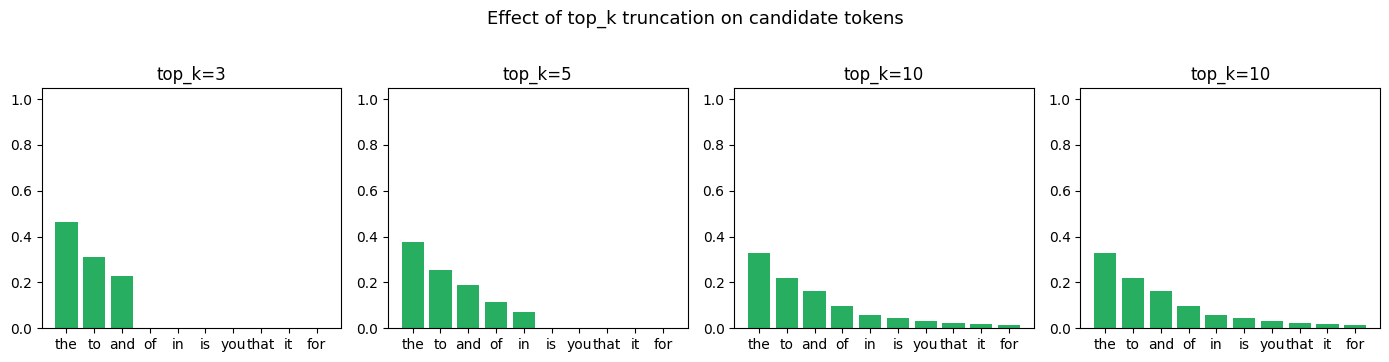

SmolLM2 词表共 49,152 个 token，top_k=50 只保留前 50 个
保留比例: 0.10%


In [16]:
import torch
import matplotlib.pyplot as plt

K_list = [3, 5, 10, len(tokens)]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, K in zip(axes, K_list):
    topk_indices = sorted_indices[:K]
    topk_probs = probs[topk_indices]
    topk_probs = topk_probs / topk_probs.sum()
    display = torch.zeros_like(probs)
    display[topk_indices] = topk_probs
    colors = ['#27AE60' if i in topk_indices else '#BDC3C7' for i in range(len(tokens))]
    ax.bar(range(len(tokens)), display.numpy(), color=colors)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"top_k={K}")

plt.suptitle("Effect of top_k truncation on candidate tokens", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"SmolLM2 词表共 {V:,} 个 token，top_k={generation_config['top_k']} 只保留前 {generation_config['top_k']} 个")
print(f"保留比例: {generation_config['top_k'] / V * 100:.2f}%")


**温度 + top_p + top_k 叠加效果**

实际生成时三个参数会同时影响候选分布；很多实现会先用 temperature 改变 logits 间距，再做 top_k / top_p 过滤，但具体顺序以框架实现为准。
下面模拟不同组合，看最终哪些 token 能"活下来"。

In [17]:
import torch

def sample_filter(all_tokens, logits, T=1.0, top_k=None, top_p=None):
    """应用 temperature、top_k、top_p 后返回保留的 token 列表"""
    scaled = logits / T
    probs = torch.softmax(scaled, dim=-1)
    allowed = torch.ones_like(probs, dtype=torch.bool)

    # top_k 不能超过词表大小
    k = min(top_k, len(all_tokens)) if top_k is not None else None
    if k is not None:
        topk_vals, _ = torch.topk(probs, k)
        threshold = topk_vals[-1]
        allowed = allowed & (probs >= threshold)

    if top_p is not None:
        sorted_p, sorted_i = torch.sort(probs, descending=True)
        cum = torch.cumsum(sorted_p, dim=-1)
        n_keep = min((cum <= top_p).sum().item() + 1, len(all_tokens))
        keep_i = sorted_i[:n_keep]
        mask = torch.zeros_like(probs, dtype=torch.bool)
        mask[keep_i] = True
        allowed = allowed & mask

    return [all_tokens[i] for i in range(len(all_tokens)) if allowed[i]]

# 三种配置（top_k 改为适合 demo 词表大小的值）
configs = [
    ("保守采样", 0.3, 3, 0.85),
    ("贪心 (T→0)", 0.001, None, None),
    ("创意模式", 1.2, None, 0.95),
]

logits_np = logits.clone()
print(f"{'配置':<20} {'保留 token'}")
print("-" * 50)
for name, T, tk, tp in configs:
    kept = sample_filter(tokens, logits_np, T=T, top_k=tk, top_p=tp)
    print(f"{name:<20} {kept}")

print(f"\n关键观察：三个参数叠加后，最终候选 token 是它们的交集。")
print(f"  贪心模式只有最高概率的 token 能存活 = 确定性生成")
print(f"  创意模式保留更多候选 = 输出更多样")


配置                   保留 token
--------------------------------------------------
保守采样                 ['the', 'to']
贪心 (T→0)             ['the', 'to', 'and', 'of', 'in', 'is', 'you', 'that', 'it', 'for']
创意模式                 ['the', 'to', 'and', 'of', 'in', 'is', 'you', 'that']

关键观察：三个参数叠加后，最终候选 token 是它们的交集。
  贪心模式只有最高概率的 token 能存活 = 确定性生成
  创意模式保留更多候选 = 输出更多样


## 三张表串起来：一个请求的完整旅程

现在把 config.json、tokenizer_config.json、generation_config.json 串起来看：一个文本从输入到输出的完整路径上，每张表分别在哪个环节起作用。

In [18]:
print("输入文本: '我爱机器学习'")
print()
print("  ┌─────────────────────────────┐")
print("  │  tokenizer_config.json      │")
print("  │  · add_bos_token = True      │  ← 自动加 <|im_start|>")
print("  │  · add_eos_token = True      │  ← 自动加 <|im_end|>")
print("  │  · model_max_length = 8192   │  ← 超过就截断")
print("  └──────────────┬──────────────┘")
print("                 │ token IDs")
print("                 ▼")
print("  ┌─────────────────────────────┐")
print("  │  config.json                │")
print("  │  · hidden_size = 576         │  ← Embedding 向量维度")
print("  │  · num_hidden_layers = 30    │  ← 经过 30 层 Block")
print("  │  · num_attention_heads = 9   │  ← GQA 注意力")
print("  │  · intermediate_size = 1536  │  ← FFN 中间维度")
print("  │  · vocab_size = 49152        │  ← 输出 49152 个 logits")
print("  └──────────────┬──────────────┘")
print("                 │ logits [1, 49152]")
print("                 ▼")
print("  ┌─────────────────────────────┐")
print("  │  generation_config.json     │")
print("  │  · temperature = 0.6         │  ← 调尖锐度")
print("  │  · top_k = 50                │  ← 只要前 50 个")
print("  │  · top_p = 0.9               │  ← 累积概率到 90%")
print("  │  · max_new_tokens = 256      │  ← 最多生成 256 个")
print("  └──────────────┬──────────────┘")
print("                 │ 选中的 token ID")
print("                 ▼")
print("           输出: '机器学习很有意思。'")
print()
print("三张表分工明确：tokenizer_config 管入，config 管算，generation_config 管出。")
print("更换其中任何一张表，行为就会发生变化——这就是为什么你看不同模型")
print("的 config 差异能理解它们的设计思路。")

输入文本: '我爱机器学习'

  ┌─────────────────────────────┐
  │  tokenizer_config.json      │
  │  · add_bos_token = True      │  ← 自动加 <|im_start|>
  │  · add_eos_token = True      │  ← 自动加 <|im_end|>
  │  · model_max_length = 8192   │  ← 超过就截断
  └──────────────┬──────────────┘
                 │ token IDs
                 ▼
  ┌─────────────────────────────┐
  │  config.json                │
  │  · hidden_size = 576         │  ← Embedding 向量维度
  │  · num_hidden_layers = 30    │  ← 经过 30 层 Block
  │  · num_attention_heads = 9   │  ← GQA 注意力
  │  · intermediate_size = 1536  │  ← FFN 中间维度
  │  · vocab_size = 49152        │  ← 输出 49152 个 logits
  └──────────────┬──────────────┘
                 │ logits [1, 49152]
                 ▼
  ┌─────────────────────────────┐
  │  generation_config.json     │
  │  · temperature = 0.6         │  ← 调尖锐度
  │  · top_k = 50                │  ← 只要前 50 个
  │  · top_p = 0.9               │  ← 累积概率到 90%
  │  · max_new_tokens = 256      │  ← 最多生成 256 个
  └────────────

## 小结

- HuggingFace 模型仓库里有 3 张核心 JSON 表：config.json、tokenizer_config.json、generation_config.json
- config.json 的每个数字都能对应到一个具体的 PyTorch 模块：Embedding、Q/K/V/O、FFN、RMSNorm
- hidden_size 对应 d_model，intermediate_size 对应 FFN 的 d_ff
- GQA 通过减少 KV 头数来节省参数和显存：K 投影参数只有 Q 的 1/3
- Llama 的 FFN 比教学版多了 gate 矩阵（三权重 vs 两权重），用 SiLU 做门控
- RMSNorm 不做均值中心化，通常也没有 LayerNorm 的 beta 平移参数；它主要改变归一化方式，省参数只是附带差异
- tokenizer_config.json 控制 BOS/EOS 插入、padding 方向和最大长度
- generation_config.json 的三个核心参数（temperature、top_p、top_k）共同决定采样行为
- 更换其中任何一张表，模型的行为就会发生变化

学会了读这几张表，就等于有了一份模型的完整说明书。随便打开 HuggingFace 上一个新模型，先看 config.json 的结构尺寸，再看 tokenizer_config.json 的特殊 token，最后看 generation_config.json 的采样策略——三张表读完，这个模型的设计思路就清楚了。

## 作业

> 可以让 AI 帮忙解释思路，但不建议直接让 AI「做完这道题」。

**作业 1：比较两个模型的 generation_config**

在 HuggingFace 上找两个不同用途的模型（比如一个通用对话模型和一个代码生成模型），比较它们的 generation_config.json，指出三处关键差异，并解释为什么。

小提示：代码生成通常 temperature 更低，repetition_penalty 更高。

In [ ]:
# 作业 1：比较两个模型的 generation_config
# 示例：在浏览器打开下面两个 URL
#   https://huggingface.co/HuggingFaceTB/SmolLM2-135M/blob/main/generation_config.json
#   https://huggingface.co/Qwen/Qwen2.5-0.5B/blob/main/generation_config.json

# TODO：写出三个差异和你的解释
diff_1 = """差异 1 和你的解释"""
diff_2 = """差异 2 和你的解释"""
diff_3 = """差异 3 和你的解释"""

print("完成作业 1：请替换上面的占位内容，然后取消下面 assert 的注释来验证")
# assert all(not d.startswith('"""') for d in [diff_1, diff_2, diff_3]), "请先替换占位内容"
# print("作业 1 通过")

**作业 2：自己搭建一个 config → 模块的映射**

修改下面的 config 参数，然后运行 cell，看参数量和形状怎么变化。
比如把 hidden_size 从 576 改成 768，看总参数量变成多少。

小提示：关注 hidden_size 变化后，哪些组件的参数量会受影响。

In [ ]:
# 作业 2：修改 config 观察参数量变化
my_config = {
    "vocab_size": 49152,
    "hidden_size": 576,        # TODO: 试试改成 768
    "num_hidden_layers": 30,   # TODO: 试试改成 12
    "num_attention_heads": 9,
    "num_key_value_heads": 3,
    "intermediate_size": 1536, # TODO: 试试改成 2048
}

V2, D2, L2, H2, KV2, FF2 = (my_config[k] for k in (
    "vocab_size", "hidden_size", "num_hidden_layers",
    "num_attention_heads", "num_key_value_heads", "intermediate_size"))
hd2 = D2 // H2

emb_p = V2 * D2
attn_p = D2 * H2 * hd2 + D2 * KV2 * hd2 * 2 + H2 * hd2 * D2
ffn_p = 3 * D2 * FF2
total_p = emb_p + L2 * (attn_p + ffn_p + 2 * D2) + D2

print(f"修改后总参数量: {total_p:,} ≈ {total_p/1e6:.1f}M")
print(f"  Embedding: {emb_p:,}")
print(f"  每层: {attn_p + ffn_p + 2*D2:,}")
print(f"  {L2} 层: {(attn_p + ffn_p + 2*D2) * L2:,}")

**作业 3：用估算公式预测 LLaMA-7B 的参数量**

当模型规模较大时，逐个模块算参数量太繁琐。工程上常用一个经验公式快速估算：

$$P \approx V \cdot d + L \cdot 12 d^2$$

其中 $V$ 是词表大小，$d$ 是 hidden_size，$L$ 是层数。$12 d^2$ 来自每层 Block（Attention 约 $4 d^2$，FFN 约 $8 d^2$）。

用 LLaMA-7B 的真实配置验证这个公式：$d = 4096$，$L = 32$，$V = 32000$。

小提示：先单独算 Embedding 项（$V \cdot d$）和单层 Block 项（$12 d^2$），再看哪一项占主导。

In [ ]:
# 作业 3：参数量估算公式验证
d = 4096
L = 32
vocab_size = 32000

# TODO: Embedding 层参数量（token embedding 矩阵的大小）
embedding_params = None  # vocab_size * d

# TODO: 单层 Block 参数量（用经验公式 12 * d^2）
block_params = None

# TODO: 总参数量 = Embedding + L 层 Block
total_params = None

# 验证
assert embedding_params is not None, "请先计算 embedding_params"
assert block_params is not None, "请先计算 block_params"
assert total_params is not None, "请先计算 total_params"

expected_emb = vocab_size * d
expected_block = 12 * d * d
expected_total = expected_emb + L * expected_block

assert embedding_params == expected_emb
assert block_params == expected_block
assert total_params == expected_total

print(f"✅ 作业 3 通过")
print(f"   Embedding: {embedding_params/1e9:.2f}B ({embedding_params/expected_total:.1%})")
print(f"   单层 Block: {block_params/1e6:.0f}M")
print(f"   {L} 层 Block: {L*block_params/1e9:.2f}B")
print(f"   总参数量: {total_params/1e9:.2f}B")
print(f"   公式估算约 6.9B，和 LLaMA-7B 实际的 ~6.7B 非常接近。")

## 参考资料

- [SmolLM2-135M 模型仓库](https://huggingface.co/HuggingFaceTB/SmolLM2-135M/tree/main) — 本节分析的所有 JSON 文件的来源
- Touvron et al., [LLaMA: Open and Efficient Foundation Language Models](https://arxiv.org/abs/2302.13971), 2023
- Su et al., [RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864), 2021
- Ainslie et al., [GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245), 2023
- Holtzman et al., [The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751), 2020 — top_p (nucleus sampling) 原始论文